# Managed-Futures Sleeve — the quant teardown 🧯

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Bonds_in_disguise%3F: Busted](https://img.shields.io/badge/Bonds_in_disguise%3F-Busted-8b949e?style=flat-square)

**Claim under test:** a 10-20% trend-following sleeve improves a 60/40 — near-zero correlation plus 2022-style crisis alpha.

**Dedup guard:** [31-trade-winds](../../31-trade-winds/) and [518-time-series-momentum](../../518-time-series-momentum/) already graded the *standalone* TSMOM premium **Weak** on this desk. We cite that and do not re-litigate it; the unit under test here is the **portfolio improvement**, whose decisive statistics are (1) the sleeve's **Newey-West alpha on the 60/40** (the mean-variance criterion for a beneficial addition), (2) a **paired moving-block bootstrap of ΔSharpe**, (3) the **correlation with a Fisher-z CI**, and (4) the **2022 attribution**.

**Construction:** 12-mo TSMOM (sign of trailing 12-month return) on the shared 18-futures panel, 40%/σ inverse-vol per contract / N_active, monthly rebalance, **exactly one month of execution lag** (signal & vol through month-end t−1, held month t), **5 bps one-way × traded notional** (2/10 shown); futures shorts post margin, **no borrow fee** (unfunded margin instruments). The blended sleeve is cash-collateralised (rf + excess) and pays the live wrapper's **0.85%/yr fee**. All Sharpe races are **excess-vs-excess** (^IRX). Numbers quoted from [`docs/results.md`](../docs/results.md); heavy bootstraps re-run light here.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from managed_futures_allocation import data, strategy as st

SLEEVE, FEE, COST_BPS = 0.15, 0.0085, 5.0
HAVE_REAL = data.have_real()
if HAVE_REAL:
    FUT = data.load_futures()
    FM = data.drop_partial_last_month(data.monthly_from_daily_returns(FUT), FUT.index.max())
    ETFS = data.load_etfs()
    TR = data.monthly_total_returns(ETFS[["SPY", "VBMFX", "DBMF", "KMLM"]])
    RF = data.monthly_rf(ETFS["^IRX"])
    BOOK = st.tsmom_book(FM, lookback=12, cost_bps=COST_BPS)
    P6040_FULL = st.portfolio_6040(TR["SPY"], TR["VBMFX"])
    IDX = P6040_FULL.index.intersection(BOOK["net"].index).intersection(RF.dropna().index)
    P6040, RF_I = P6040_FULL.loc[IDX], RF.loc[IDX]
    E6040 = P6040 - RF_I
    MF_NET = BOOK["net"].loc[IDX]           # futures excess, net of turnover costs
    MF_FUNDED = RF_I + MF_NET               # cash-collateralised sleeve (gross of ETF fee)
    BLEND = st.blend_returns(P6040, MF_NET, RF_I, SLEEVE, FEE)
else:
    FUT = FM = ETFS = TR = RF = BOOK = None
    P6040 = RF_I = E6040 = MF_NET = MF_FUNDED = BLEND = None
print("real caches present:", HAVE_REAL,
      "| joint months:", (0 if P6040 is None else len(P6040)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-03', 'joint_start': '2001-09-30', 'joint_end': '2026-05-31', 'n_months': 297, 'fingerprint': '2f0e9858dde3', 'fut_fp': 'b1cdf7bc6129', 'book': {'sharpe': 0.407, 'nw_t': 2.05, 'vol': 18.4, 'maxdd': -29.6, 'cagr': 7.73, 'lev': 3.71, 'turn': 1.12}, 'corr_6040': (-0.054, -0.167, 0.06, 297), 'corr_stocks': (-0.053, -0.166, 0.061, 297), 'corr_bonds': (-0.021, -0.135, 0.093, 297), 'corr_dbmf': (-0.212, -0.408, 0.002, 84), 'corr_kmlm': (-0.432, -0.611, -0.21, 65), 'corr_dbmf_book': (0.682, 0.547, 0.783, 84), 'p6040': {'cagr': 7.52, 'vol': 9.37, 'sharpe': 0.643, 'maxdd': -32.4, 'mar': 0.232}, 'blend': {'cagr': 7.72, 'vol': 8.29, 'sharpe': 0.738, 'maxdd': -23.4, 'mar': 0.33}, 'alpha': {'ann': 8.13, 't': 2.1, 'beta': -0.107, 'r2': 0.3}, 'dsharpe': {'obs': 0.095, 'lo': -0.064, 'hi': 0.242, 'p': 0.119, 'draws': 5000, 'block': 6}, 'sleeves': [(10, 0.713, -26.5, 0.07, -0.031, 0.162, 0.08), (15, 0.738, -23.4, 0.095, -0.064, 0.242, 0.119), (20, 0.753, -20.2, 0.11, -0.111, 0.317, 0.164)], 'costs': [(2.0, 8.52, 2.2), (5.0, 8.13, 2.1), (10.0, 7.46, 1.92)], 'lookbacks': [(9, 0.209, 1.35, 0.045), (12, 0.407, 2.1, 0.095), (15, 0.352, 1.67, 0.06)], 'nw_lags': [(3, 2.06), (6, 2.1), (12, 2.25)], 'subperiods': [('2001-09 - 2008-12', -0.08, 0.17, 0.257, 0.69), ('2009-01 - 2019-12', 1.2, 1.09, -0.107, 0.1), ('2020-01 - 2026-05', 0.63, 0.78, 0.147, 0.55)], 'y2022': {'spy': -18.18, 'bonds': -13.24, 'p6040': -15.91, 'sleeve': 33.13, 'blend': -9.02, 'dbmf': 21.6, 'kmlm': 24.24, 'contrib': 5.0}, 'bonds_axis': {'corr': -0.021, 'beta': -0.093, 'r2': 0.0, 'p4555_sharpe': 0.664, 'p4555_dd': -24.1, 'p4555_2022': -15.15}, 'live': {'start': '2019-07-31', 'end': '2026-06-30', 'n': 84, 'dbmf_cagr': 8.85, 'dbmf_vol': 11.4, 'dbmf_sharpe': 0.562, 'dbmf_dd': -17.3, 's6040': 0.671, 'dd6040': -20.1, 'sblend': 0.79, 'ddblend': -13.5, 'ds': 0.119, 'lo': -0.048, 'hi': 0.279, 'p': 0.09}, 'placebo': {'seeds': 24, 'book_sharpe': -0.23, 'book_sd': 0.197, 'ds': -0.0772, 'ds_sd': 0.0448}, 'syn': [(0.0, -0.026, -0.106, 0.062, 0.697, 0.0), (0.8, 0.156, 0.077, 0.246, 0.0, 4.45)]}


real caches present: True | joint months: 297


## 0 · Data stamp

In [2]:
if HAVE_REAL:
    try:
        from quantlab import repro
        joint = pd.concat([P6040, MF_NET, RF_I], axis=1)
        joint.columns = ['p6040', 'mf_net', 'rf']
        print('fingerprint(joint) =', repro.fingerprint(joint),
              ' (frozen:', R['fingerprint'] + ')')
        print('fingerprint(futures monthly) =', repro.fingerprint(FM),
              ' (frozen:', R['fut_fp'] + ')')
    except Exception as e:
        print('quantlab.repro unavailable:', e)
    print(f'futures: {FUT.shape[0]} days x {FUT.shape[1]} contracts, '
          f'{FUT.index.min().date()} -> {FUT.index.max().date()} (partial last month dropped)')
    print(f'joint window: {P6040.index.min().date()} -> {P6040.index.max().date()} '
          f'({len(P6040)} months)')
    print(f"book: avg gross leverage {BOOK['leverage']:.2f}x, "
          f"avg turnover {BOOK['turnover'].mean():.2f}x NAV/mo")


fingerprint(joint) = 2f0e9858dde3  (frozen: 2f0e9858dde3)
fingerprint(futures monthly) = b1cdf7bc6129  (frozen: b1cdf7bc6129)
futures: 6547 days x 18 contracts, 2000-07-18 -> 2026-06-11 (partial last month dropped)
joint window: 2001-09-30 -> 2026-05-31 (297 months)
book: avg gross leverage 3.71x, avg turnover 1.12x NAV/mo


> ⚠️ **Panel caveats (named on the Signal axis).** The 18 contracts are liquid futures *still trading in 2026* — mild survivorship (TSMOM shorts a faller rather than deleting it, so far weaker than an equity sort, but named). Continuous series are yfinance front-month splices (study 31's roll construction). The replication is gross of slippage beyond the modeled bps — its 2022 (+33%) vs DBMF's live +21.6% shows the flattering gap. The **live ETFs are the honest net tape** and get their own section.

## 1 · The sleeve itself (context only — the premium is the siblings' fight)

> 💡 **In plain words:** before asking whether the sleeve helps the portfolio, look at what it is: a diversified trend book that earns a positive but modest return with big swings — mediocre alone, interesting only for *when* it earns.

In [3]:
if HAVE_REAL:
    s = st.ann_stats(MF_FUNDED, RF_I)
    print(f'net excess Sharpe {st.sharpe_excess(MF_NET):.3f}   '
          f'NW t(mean) {st.nw_tstat(MF_NET):+.2f}   vol {s["vol"]*100:.1f}%   '
          f'maxDD {s["maxdd"]*100:.1f}%   CAGR(funded) {s["cagr"]*100:.2f}%')
    print('(standalone premium graded Weak by studies 31 & 518 — cited, not re-litigated)')


net excess Sharpe 0.407   NW t(mean) +2.05   vol 18.4%   maxDD -29.6%   CAGR(funded) 7.73%
(standalone premium graded Weak by studies 31 & 518 — cited, not re-litigated)


## 2 · Axis 1a — "near-zero correlation": decisively real

Fisher-z 95% CIs on monthly excess returns. The rolling window shows the property is not an average of +0.5 and −0.5 regimes — it hugs zero throughout.

corr(MF, 60/40) = -0.054  95% CI [-0.167, +0.060]  n=297
corr(MF, stocks) = -0.053  95% CI [-0.166, +0.061]  n=297
corr(MF, bonds ) = -0.021  95% CI [-0.135, +0.093]  n=297


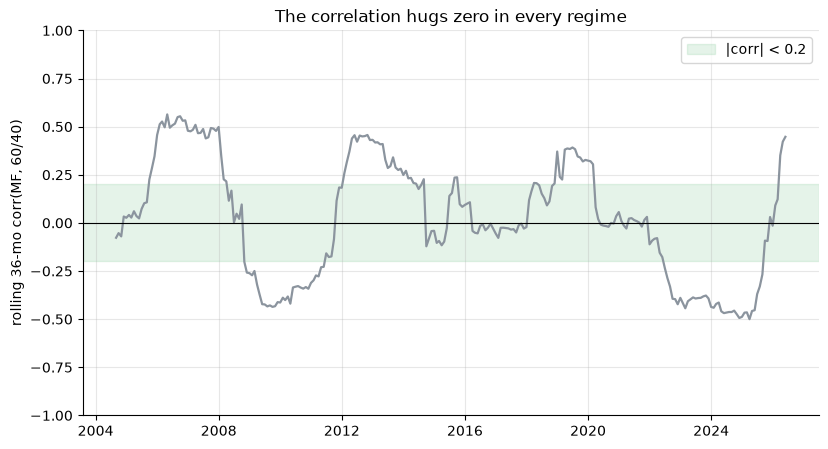

In [4]:
if HAVE_REAL:
    for lab, x_ in [('60/40', E6040), ('stocks', TR['SPY'].loc[IDX]-RF_I),
                    ('bonds ', TR['VBMFX'].loc[IDX]-RF_I)]:
        c = st.corr_ci(MF_NET, x_)
        print(f'corr(MF, {lab}) = {c["r"]:+.3f}  95% CI [{c["lo"]:+.3f}, {c["hi"]:+.3f}]  n={c["n"]}')
    roll = MF_NET.rolling(36).corr(E6040)
    fig, ax = plt.subplots()
    ax.plot(roll.index, roll, color=GREY, lw=1.6)
    ax.axhline(0, color='k', lw=.8)
    ax.axhspan(-0.2, 0.2, color=GREEN, alpha=.12, label='|corr| < 0.2')
    ax.set_ylim(-1, 1); ax.set_ylabel('rolling 36-mo corr(MF, 60/40)')
    ax.set_title('The correlation hugs zero in every regime')
    ax.legend()
    plt.show()


Frozen: corr(MF, 60/40) = **-0.054** [-0.167, +0.060] (n=297); live DBMF **-0.212**, KMLM **-0.432** (both negative). This half of the claim clears any reasonable bar.

> 💡 **In plain words:** "uncorrelated" survives every test we throw at it. The fight is over whether uncorrelated-plus-weak-return actually *improves* the portfolio.

## 3 · Axis 1b — the improvement: point estimates vs inference

Two complementary tests. **(a)** The mean-variance criterion: regress sleeve excess on 60/40 excess — a positive NW alpha means the sleeve expands the attainable frontier. **(b)** The direct object: ΔSharpe of the 15% blend, with a paired moving-block bootstrap (joint rows resampled in blocks of 6, so the cross-correlation survives; Ledoit-Wolf spirit).

In [5]:
if HAVE_REAL:
    a = st.ann_stats(P6040, RF_I); b = st.ann_stats(BLEND, RF_I)
    print('               CAGR    vol   Sharpe  maxDD    MAR')
    print(f"60/40        : {a['cagr']*100:5.2f}%  {a['vol']*100:5.2f}%  {a['sharpe']:.3f}  "
          f"{a['maxdd']*100:5.1f}%  {a['mar']:.3f}")
    print(f"+15% sleeve  : {b['cagr']*100:5.2f}%  {b['vol']*100:5.2f}%  {b['sharpe']:.3f}  "
          f"{b['maxdd']*100:5.1f}%  {b['mar']:.3f}")
    al = st.nw_alpha(MF_NET, E6040, lags=6)
    print(f"\nMF alpha vs 60/40: {al['alpha_ann']*100:+.2f}%/yr  NW t = {al['t_alpha']:+.2f}  "
          f"beta {al['beta']:+.3f}  R^2 {al['r2']*100:.1f}%")
    # light bootstrap re-run (canonical = 5,000 draws in docs/results.md)
    bs = st.bootstrap_dsharpe(E6040, MF_NET, SLEEVE, FEE, n_draws=1500, seed=595)
    print(f"dSharpe {bs['obs']:+.3f}  95% CI [{bs['lo']:+.3f}, {bs['hi']:+.3f}]  "
          f"p(one-sided) {bs['p_onesided']:.3f}   (light 1,500-draw rerun; frozen: "
          f"{R['dsharpe']['obs']:+.3f} [{R['dsharpe']['lo']:+.3f}, {R['dsharpe']['hi']:+.3f}], "
          f"p {R['dsharpe']['p']:.3f})")


               CAGR    vol   Sharpe  maxDD    MAR
60/40        :  7.52%   9.37%  0.643  -32.4%  0.232
+15% sleeve  :  7.72%   8.29%  0.738  -23.4%  0.330

MF alpha vs 60/40: +8.13%/yr  NW t = +2.10  beta -0.107  R^2 0.3%


dSharpe +0.095  95% CI [-0.064, +0.237]  p(one-sided) 0.124   (light 1,500-draw rerun; frozen: +0.095 [-0.064, +0.242], p 0.119)


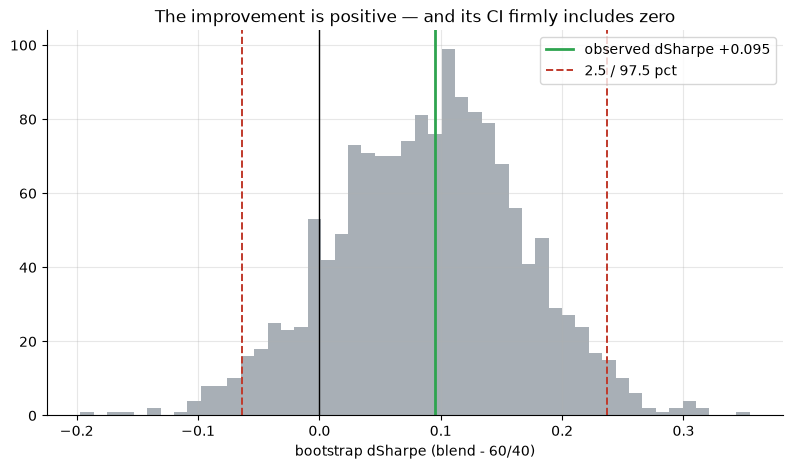

In [6]:
if HAVE_REAL:
    # bootstrap distribution figure
    df = pd.concat([E6040, MF_NET], axis=1).dropna()
    av = df.iloc[:,0].to_numpy(); bv = df.iloc[:,1].to_numpy() - FEE/12
    rng = np.random.default_rng(595); n = len(av); block = 6
    nb_ = int(np.ceil(n/block)); draws = []
    for _ in range(1500):
        stt = rng.integers(0, n-block+1, size=nb_)
        ii = (stt[:,None] + np.arange(block)[None,:]).ravel()[:n]
        aa, bb = av[ii], (1-SLEEVE)*av[ii] + SLEEVE*bv[ii]
        draws.append((bb.mean()/bb.std() - aa.mean()/aa.std())*np.sqrt(12))
    draws = np.array(draws)
    fig, ax = plt.subplots()
    ax.hist(draws, bins=50, color=GREY, alpha=.75)
    ax.axvline(0, color='k', lw=1)
    ax.axvline(R['dsharpe']['obs'], color=GREEN, lw=2,
               label=f"observed dSharpe {R['dsharpe']['obs']:+.3f}")
    ax.axvline(np.percentile(draws, 2.5), color=RED, ls='--', lw=1.4, label='2.5 / 97.5 pct')
    ax.axvline(np.percentile(draws, 97.5), color=RED, ls='--', lw=1.4)
    ax.set_xlabel('bootstrap dSharpe (blend - 60/40)')
    ax.set_title('The improvement is positive — and its CI firmly includes zero')
    ax.legend()
    plt.show()


Frozen headline: Sharpe **0.643 → 0.738**, maxDD **-32.4% → -23.4%**, MAR 0.232 → 0.330; alpha **+8.13%/yr, NW t = +2.10**; ΔSharpe **+0.095**, CI **[-0.064, +0.242]**, p = 0.119.

> 💡 **In plain words:** every point estimate says "better" — but the direct test of the claimed quantity never excludes zero, and the alpha's t = 2.10 clears the bar only at the exact headline configuration. That gap between *plausible* and *certified* is the whole verdict.

## 4 · Robustness — where the t = 2.10 breaks

In [7]:
if HAVE_REAL:
    print('sleeve-size (frozen 5,000-draw CIs):')
    for pct, sh, dd, ds, lo, hi, p in R['sleeves']:
        print(f'  {pct}%: Sharpe {sh:.3f}  maxDD {dd}%  dS {ds:+.3f}  CI [{lo:+.3f}, {hi:+.3f}]  p {p:.3f}')
    print('\ncost sweep (alpha NW t):')
    for cb, alp, t_ in R['costs']:
        print(f'  {cb:>4.1f} bps: alpha {alp:+.2f}%/yr  t {t_:+.2f}')
    print('\nlookback sweep — recomputed live:')
    for lb in (9, 12, 15):
        bk = st.tsmom_book(FM, lookback=lb, cost_bps=COST_BPS)
        em = bk['net'].reindex(IDX).dropna(); e6 = E6040.reindex(em.index)
        al2 = st.nw_alpha(em, e6, lags=6)
        print(f'  {lb:>2d}m: book Sharpe {st.sharpe_excess(em):.3f}  alpha NW t {al2["t_alpha"]:+.2f}')
    print('\nNW lags (12m, 5bp): ' + '  '.join(
        f'lags={lg}: t={st.nw_alpha(MF_NET, E6040, lags=lg)["t_alpha"]:+.2f}' for lg in (3, 6, 12)))


sleeve-size (frozen 5,000-draw CIs):
  10%: Sharpe 0.713  maxDD -26.5%  dS +0.070  CI [-0.031, +0.162]  p 0.080
  15%: Sharpe 0.738  maxDD -23.4%  dS +0.095  CI [-0.064, +0.242]  p 0.119
  20%: Sharpe 0.753  maxDD -20.2%  dS +0.110  CI [-0.111, +0.317]  p 0.164

cost sweep (alpha NW t):
   2.0 bps: alpha +8.52%/yr  t +2.20
   5.0 bps: alpha +8.13%/yr  t +2.10
  10.0 bps: alpha +7.46%/yr  t +1.92

lookback sweep — recomputed live:
   9m: book Sharpe 0.209  alpha NW t +1.35
  12m: book Sharpe 0.407  alpha NW t +2.10
  15m: book Sharpe 0.352  alpha NW t +1.67

NW lags (12m, 5bp): lags=3: t=+2.06  lags=6: t=+2.10  lags=12: t=+2.25


Only the canonical **12-month** lookback at **≤5 bps** clears t = 2 (its 9m/15m neighbours: t = 1.35 / 1.67; 10 bps: t = 1.92). A bar cleared only at the snoopable textbook config is not a certified effect — the same fragility 518 found on the standalone premium reappears at the portfolio level, as it must.

> 💡 **In plain words:** if you have to pick the one exact recipe the papers use to get "significant", it isn't robustly significant.

## 5 · Regime dependence — the 2009-2019 drought

2001-09 -> 2008-12: 60/40 -0.08  blend +0.17  dSharpe +0.257
2009-01 -> 2019-12: 60/40 +1.20  blend +1.09  dSharpe -0.107
2020-01 -> 2026-05: 60/40 +0.63  blend +0.78  dSharpe +0.147


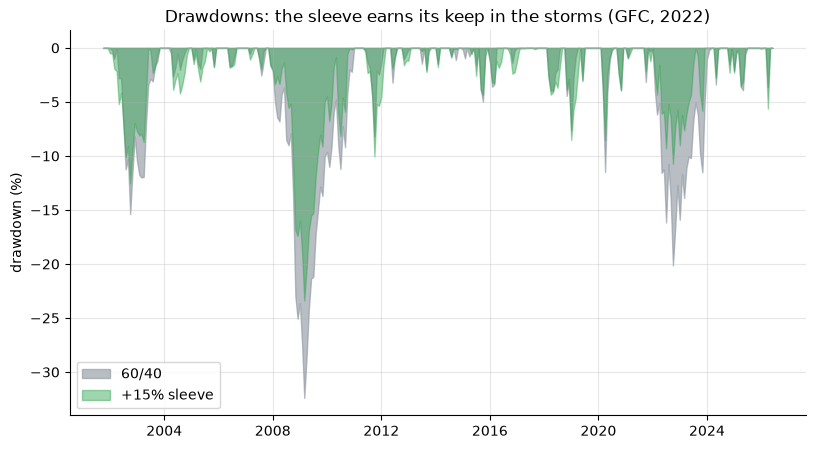

In [8]:
if HAVE_REAL:
    for lo, hi in [('2001-09', '2008-12'), ('2009-01', '2019-12'), ('2020-01', '2026-05')]:
        sl_ = slice(pd.Timestamp(lo), pd.Timestamp(hi) + pd.offsets.MonthEnd(0))
        s60 = st.sharpe_excess(E6040.loc[sl_])
        sbl = st.sharpe_excess((BLEND - RF_I).loc[sl_])
        print(f'{lo} -> {hi}: 60/40 {s60:+.2f}  blend {sbl:+.2f}  dSharpe {sbl-s60:+.3f}')
    w60 = (1 + P6040).cumprod(); wbl = (1 + BLEND).cumprod()
    dd60 = w60/w60.cummax() - 1; ddbl = wbl/wbl.cummax() - 1
    fig, ax = plt.subplots()
    ax.fill_between(dd60.index, dd60*100, 0, color=GREY, alpha=.6, label='60/40')
    ax.fill_between(ddbl.index, ddbl*100, 0, color=GREEN, alpha=.45, label='+15% sleeve')
    ax.set_ylabel('drawdown (%)')
    ax.set_title('Drawdowns: the sleeve earns its keep in the storms (GFC, 2022)')
    ax.legend(loc='lower left')
    plt.show()


ΔSharpe by regime: **+0.257** (2001-2008) · **−0.107** (2009-2019) · **+0.147** (2020-2026). An eleven-year stretch where the sleeve made the portfolio *worse* is why the full-sample CI includes zero — and why the product is behaviourally hard to hold. This is the Tradability axis's decisive fact.

## 6 · 2022 attribution — the crisis-alpha year

In [9]:
if HAVE_REAL:
    for name, ser in [('SPY', TR['SPY']), ('VBMFX', TR['VBMFX']), ('60/40', P6040),
                      ('sleeve (funded, net)', MF_FUNDED), ('blend', BLEND),
                      ('DBMF live', TR['DBMF']), ('KMLM live', TR['KMLM'])]:
        print(f'  {name:<22s}: {st.calendar_year_return(ser, 2022)*100:+7.2f}%')
    print(f"  sleeve contribution to blend ~ +{0.15*st.calendar_year_return(MF_FUNDED, 2022)*100:.1f} pp")


  SPY                   :  -18.18%
  VBMFX                 :  -13.24%
  60/40                 :  -15.91%
  sleeve (funded, net)  :  +33.13%
  blend                 :   -9.02%
  DBMF live             :  +21.60%
  KMLM live             :  +24.24%
  sleeve contribution to blend ~ +5.0 pp


One calendar year — descriptive, no significance test possible (and we don't run one). But it is the exact scenario the product is sold on, delivered live and net of fees (DBMF +21.6%, KMLM +24.2%) in the only post-inception test the market has offered.

## 7 · Third axis — bonds in disguise? **BUSTED**

The skeptic's null: "trend funds are mostly long fixed-income carry; the sleeve is leveraged duration, so just buy more bonds." Three tests:

In [10]:
if HAVE_REAL:
    eb = TR['VBMFX'].loc[IDX] - RF_I
    alb = st.nw_alpha(MF_NET, eb, lags=6)
    cb_ = st.corr_ci(MF_NET, eb)
    print(f'1) loading: corr(MF, bonds) = {cb_["r"]:+.3f} [{cb_["lo"]:+.3f}, {cb_["hi"]:+.3f}]  '
          f'beta {alb["beta"]:+.3f}  R^2 {alb["r2"]*100:.1f}%')
    print(f'2) 2022: bonds {st.calendar_year_return(TR["VBMFX"], 2022)*100:+.2f}% vs '
          f'sleeve {st.calendar_year_return(MF_FUNDED, 2022)*100:+.2f}% — opposite signs')
    p4555 = 0.45*TR['SPY'].loc[IDX] + 0.55*TR['VBMFX'].loc[IDX]
    d = st.ann_stats(p4555, RF_I); b = st.ann_stats(BLEND, RF_I)
    print(f'3) same 15 pts into bonds instead (45/55): Sharpe {d["sharpe"]:.3f}  '
          f'maxDD {d["maxdd"]*100:.1f}%  2022 {st.calendar_year_return(p4555, 2022)*100:+.2f}%')
    print(f'   vs the sleeve blend                  : Sharpe {b["sharpe"]:.3f}  '
          f'maxDD {b["maxdd"]*100:.1f}%  2022 {st.calendar_year_return(BLEND, 2022)*100:+.2f}%')


1) loading: corr(MF, bonds) = -0.021 [-0.135, +0.093]  beta -0.093  R^2 0.0%
2) 2022: bonds -13.24% vs sleeve +33.13% — opposite signs
3) same 15 pts into bonds instead (45/55): Sharpe 0.664  maxDD -24.1%  2022 -15.15%
   vs the sleeve blend                  : Sharpe 0.738  maxDD -23.4%  2022 -9.02%


Zero bond loading (R² rounds to **0.0%**), opposite sign in the rising-rate crash (trend was *short* bonds in 2022), and the bonds-instead portfolio is worse on every line (Sharpe 0.664 vs 0.738, 2022 −15.15% vs −9.02%). The sleeve is its own animal — **busted**.

> 💡 **In plain words:** in the one year the "it's just bonds" theory could have been right, the sleeve made money *by betting against bonds*.

## 8 · The live wrappers — DBMF/KMLM (2019-07 → 2026-06, net of fees; descriptive)

The replication is gross of real-world slippage; the ETFs are the honest tape.

In [11]:
if HAVE_REAL:
    dbmf = TR['DBMF'].dropna().iloc[1:]
    lidx = dbmf.index.intersection(P6040_FULL.index).intersection(RF.dropna().index)
    p60l, rfl = P6040_FULL.loc[lidx], RF.loc[lidx]
    cd = st.corr_ci(dbmf.loc[lidx]-rfl, p60l-rfl)
    cr = st.corr_ci(dbmf.loc[lidx]-rfl, MF_NET.reindex(lidx))
    print(f'window {lidx.min().date()} -> {lidx.max().date()} ({len(lidx)} months)')
    print(f'corr(DBMF, 60/40) = {cd["r"]:+.3f} [{cd["lo"]:+.3f}, {cd["hi"]:+.3f}]')
    print(f'corr(DBMF, replication book) = {cr["r"]:+.3f} [{cr["lo"]:+.3f}, {cr["hi"]:+.3f}]')
    sd = st.ann_stats(dbmf.loc[lidx], rfl)
    print(f'DBMF: CAGR {sd["cagr"]*100:.2f}%  vol {sd["vol"]*100:.1f}%  Sharpe {sd["sharpe"]:.3f}  '
          f'maxDD {sd["maxdd"]*100:.1f}%')
    bl_l = 0.85*p60l + 0.15*dbmf.loc[lidx]
    a_l, b_l = st.ann_stats(p60l, rfl), st.ann_stats(bl_l, rfl)
    bs_l = st.bootstrap_dsharpe(p60l-rfl, dbmf.loc[lidx]-rfl, SLEEVE, 0.0, n_draws=1500, seed=595)
    print(f'60/40 Sharpe {a_l["sharpe"]:.3f} maxDD {a_l["maxdd"]*100:.1f}%  ->  +15% DBMF '
          f'Sharpe {b_l["sharpe"]:.3f} maxDD {b_l["maxdd"]*100:.1f}%')
    print(f'live dSharpe {bs_l["obs"]:+.3f}  CI [{bs_l["lo"]:+.3f}, {bs_l["hi"]:+.3f}]  '
          f'p {bs_l["p_onesided"]:.3f}   (light rerun; frozen: '
          f'{R["live"]["ds"]:+.3f} [{R["live"]["lo"]:+.3f}, {R["live"]["hi"]:+.3f}], p {R["live"]["p"]:.3f})')


window 2019-07-31 -> 2026-06-30 (84 months)
corr(DBMF, 60/40) = -0.212 [-0.408, +0.002]
corr(DBMF, replication book) = +0.682 [+0.547, +0.783]
DBMF: CAGR 8.85%  vol 11.4%  Sharpe 0.562  maxDD -17.3%


60/40 Sharpe 0.671 maxDD -20.1%  ->  +15% DBMF Sharpe 0.790 maxDD -13.5%
live dSharpe +0.119  CI [-0.054, +0.268]  p 0.098   (light rerun; frozen: +0.119 [-0.048, +0.279], p 0.090)


DBMF tracks the replication at **+0.682** (same animal), runs **-0.212** to the 60/40 live, and the live blend repeats the story: Sharpe 0.671 → 0.790, maxDD -20.1% → -13.5%, ΔSharpe +0.119 with a CI that includes zero. 84 months cannot certify a Sharpe difference — but nothing in the live tape contradicts the replication.

## 9 · Random-sign placebo — is the improvement just "any uncorrelated thing"?

Same sizing, lag, costs and fee; the trend sign replaced by an iid coin, **24 seeds** (house rule: random baselines average ≥ 20 seeds).

In [12]:
if HAVE_REAL:
    rows_p = st.random_sign_book(FM, range(1, 25), cost_bps=COST_BPS)
    shs, dss = [], []
    for r_ in rows_p:
        em = r_['net'].reindex(IDX).dropna(); e6 = E6040.reindex(em.index)
        shs.append(st.sharpe_excess(em))
        blx = (1-SLEEVE)*e6 + SLEEVE*(em - FEE/12)
        dss.append(st.sharpe_excess(blx) - st.sharpe_excess(e6))
    print(f'{len(rows_p)} seeds: mean placebo book Sharpe {np.mean(shs):+.3f} (sd {np.std(shs):.3f})')
    print(f'          mean placebo dSharpe {np.mean(dss):+.4f} (sd {np.std(dss):.4f})')
    print(f"observed trend-sleeve dSharpe: {R['dsharpe']['obs']:+.3f}")


24 seeds: mean placebo book Sharpe -0.230 (sd 0.197)
          mean placebo dSharpe -0.0772 (sd 0.0448)
observed trend-sleeve dSharpe: +0.095


A zero-edge uncorrelated sleeve **hurts** the blend (mean ΔSharpe **-0.0772**): with the fee and costs charged, "low correlation" alone is a drag, not a benefit. The observed +0.095 requires the trend signal itself — the improvement, whatever its significance, is not diversification arithmetic.

## 10 · Synthetic control — the machinery is faithful

Seeded joint (stock, bond, MF) world, 312 months, corr 0, fee charged, planted MF Sharpe as the knob. The detector must stay quiet at 0 and fire at 0.8. *(Machinery proof only — never cited in support of a stamp.)*

In [13]:
for ms in (0.0, 0.8):
    w = data.synthetic_world(n_months=312, mf_sharpe=ms, rho_bond=0.0, seed=595)
    e60s = 0.6*w['stock'] + 0.4*w['bond']
    bs_s = st.bootstrap_dsharpe(e60s, w['mf'], 0.15, 0.0085, n_draws=1000, seed=595)
    al_s = st.nw_alpha(w['mf'], e60s, lags=6)
    print(f'planted MF Sharpe {ms:.1f}: dSharpe {bs_s["obs"]:+.3f}  '
          f'CI [{bs_s["lo"]:+.3f}, {bs_s["hi"]:+.3f}]  p {bs_s["p_onesided"]:.3f}  '
          f'alpha NW t {al_s["t_alpha"]:+.2f}')


planted MF Sharpe 0.0: dSharpe -0.026  CI [-0.107, +0.056]  p 0.680  alpha NW t +0.00


planted MF Sharpe 0.8: dSharpe +0.156  CI [+0.076, +0.243]  p 0.000  alpha NW t +4.45


## Verdict

- **Signal — MIXED** *(Real on the correlation · Weak on the certified improvement)*: corr **-0.054** [-0.167, +0.060] is decisively near-zero (live wrappers negative), but ΔSharpe **+0.095** carries a CI of [-0.064, +0.242] and the alpha t = +2.10 survives only the canonical 12m/≤5bp config (9m: +1.35, 15m: +1.67, 10bp: +1.92). Mild futures-panel survivorship named.
- **Tradability — FRAGILE**: one-ticket access exists and every headline pays the 0.85%/yr fee, but the benefit is regime-dependent (2009-2019 ΔSharpe −0.107) and statistically uncertified.
- **Bonds in disguise? — BUSTED**: zero bond loading, opposite sign in 2022, and more-bonds-instead is worse on every line.

Frozen numbers: [`docs/results.md`](../docs/results.md) (fingerprint `2f0e9858dde3`). *Research & education, not investment advice.*